# Generate data, lesioning load-tuned neurons

firing rates, LFP, behavior

run after filtering down the models using filter_models_multiload.ipynb (in 0_behavior/1_model_performance folder)  

[7/1/26] UPDATE FROM V1: 
- here we're filtering by load-selective AND stim non-selective
- also going to use the double-balanced (precomputed.) dataset to calculate load selectivity 

FOR EACH MODEL
1. find neurons that are load-tuned
2. for each load tuning (ie 1, 3):
    1. lesion outgoing connections by 50% for those neurons preferring that load
    2. generate data for a balanced combo of trials
3. study performance

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

2026-07-01 13:19:35.501750: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 13:19:35.510391: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 13:19:35.521170: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 13:19:35.524165: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 13:19:35.532972: I tensorflow/core/platform/cpu_feature_guar

## delay=150, lesion load-selective

precomputed_lesion_maint_loadpref_

In [2]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

### necessary functions

In [3]:
from itertools import permutations
import random
from collections import Counter

def generate_sternberg_trialtypes_load3(stimuli, memory_set_size=3, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a Sternberg block balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations, not combinations)
      - Serial position of match probe (each position probed once per sequence)
      - Stimulus identity as match and mismatch probe
    
    Block size: 2 * P(n,k) * k = 2 * 24 * 3 = 144 trials (for 4 stimuli, set size 3)
    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                           match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))
    trial_type_all = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]
            assert len(excluded) == 1
            mismatch_probe = excluded[0]

            for pos in range(memory_set_size):
                trial_type_all.append([memory_set_size,  1] + seq + [seq[pos]])        # match
                trial_type_all.append([memory_set_size, -1] + seq + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trial_type_all)

    return np.array(trial_type_all)  # shape: (n_trials, 6)

In [ ]:
def generate_sternberg_trialtypes_load2(stimuli, memory_set_size=2, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a load-2 Sternberg block with all possible trial combinations, balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations of size 2)
      - All serial positions as match probe (2 per sequence)
      - All possible mismatch probes for each sequence (2 per sequence)

    For load 2:
      - 24 unique match trials (12 sequences x 2 serial positions)
      - 24 unique mismatch trials (12 sequences x 2 excluded stimuli)
      - Total: 48 trials per repeat

    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                            stim3 = NaN (unused at load 2)
                                            match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))  # 12 ordered sequences
    trials = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]  # 2 excluded stimuli

            # All 2 match probes (one per serial position)
            for pos in range(memory_set_size):
                trials.append([memory_set_size,  1] + seq + [float('nan')] + [seq[pos]])   # match

            # All 2 mismatch probes
            for mismatch_probe in excluded:
                trials.append([memory_set_size, -1] + seq + [float('nan')] + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trials)

    return np.array(trials, dtype=float)  # shape: (n_trials, 6)

In [4]:
def generate_sternberg_trialtypes_load1(stimuli, memory_set_size=1, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a load-1 Sternberg block with all possible trial combinations, balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations of size 1)
      - All possible mismatch probes for each sequence

    For load 1: 
      - 4 unique match trials (each stimulus shown and probed once)
      - 12 unique mismatch trials (4 sequences x 3 excluded stimuli)
      - Each match trial repeated 3x to achieve 50/50 balance
      - Total: 24 trials per repeat

    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                            stim2, stim3 = NaN (unused at load 1)
                                            match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))  # 4 single-element sequences
    trials = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]  # 3 excluded stimuli

            # All 3 mismatch probes for this sequence
            for mismatch_probe in excluded:
                trials.append([memory_set_size,  1] + seq + [float('nan'), float('nan')] + [seq[0]])          # match (repeated 3x across excluded loop)
                trials.append([memory_set_size, -1] + seq + [float('nan'), float('nan')] + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trials)

    return np.array(trials, dtype=float)  # shape: (n_trials, 6)

In [5]:
def generate_u_from_trialtypes(trial_type_all, settings):
    """
    Generate input u from trial_type_all.
    """
    n_trials = trial_type_all.shape[0]
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    
    n_channels = 4
    u_all = np.zeros((n_trials, n_channels, settings["T"]), dtype=np.float32)  # shape: (n_trials, T, n_channels)
    
    for i_trial in range(n_trials):
        u = np.zeros((n_channels, t_total), dtype=np.float32)
        stim_chan_idx = trial_type_all[i_trial, 2:-1] # stim channels are in columns 2 to -1 (excluding last column which is probe)
        stim_chan_idx = stim_chan_idx[~np.isnan(stim_chan_idx)].astype(int) # remove possible nan's from stim_chan_idx (in case of lower load)
        probe_chan_idx = trial_type_all[i_trial, -1].astype(int)
        
        for i, i_chan in enumerate(stim_chan_idx):
            if i == 0:
                u[i_chan, stim_on:stim_on+stim_dur] = 1
                ending_idx = stim_on+stim_dur
            else: # 0 bc no separation btwn stimuli
                u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
                ending_idx = ending_idx+stim_dur+0
        
        u[probe_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        u_all[i_trial] = u

    return u_all

### lesion by 50%

`precomputed_lesion_stimnan_maint_loadpref_`  
 (previously: `precomputed_lesion_maint_loadpref_`)

In [6]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

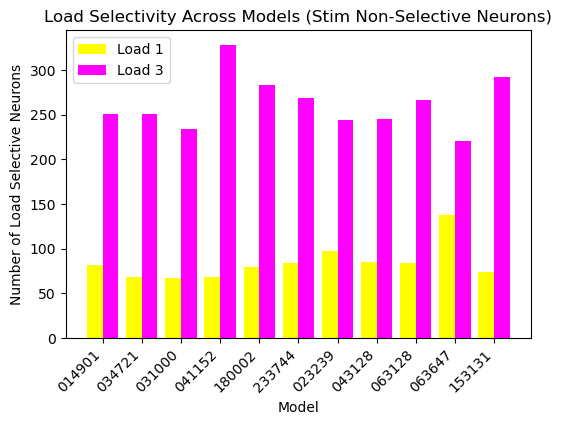

In [18]:
# visualize how many neurons are being lesioned
# load-selective but NOT STIM-SELECTIVE

condn_phrase = 'delay'
condn_num=150

n_load1 = []
n_load3 = []
for model_name in model_names: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "precomputed.",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    stim_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_nonselective = np.where(np.isnan(stim_tuning))[0]
    load_selective_stimnan = np.intersect1d(load_selective, stim_nonselective)
    load_tuning_selective = load_tuning[load_selective_stimnan]

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective_stimnan[load_tuning_selective == load] # neuron indices for this specific stimulus
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
            
plt.figure(figsize=(6,4))
plt.bar(np.arange(len(n_load1))-0.2, n_load1, width=0.4, label='Load 1', align='center', color='yellow')
plt.bar(np.arange(len(n_load3))+0.2, n_load3, width=0.4, label='Load 3', align='center', color='magenta')
plt.xticks(np.arange(len(n_load1)), [model_name[-6:] for model_name in model_names], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Number of Load Selective Neurons')
plt.title('Load Selectivity Across Models (Stim Non-Selective Neurons)')
plt.legend()
plt.show()

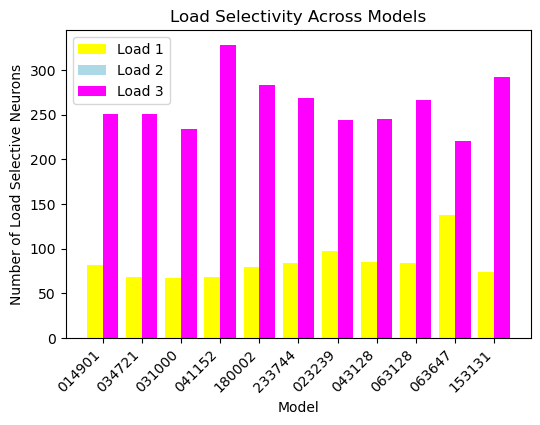

In [16]:
# visualize how many neurons are being lesioned
# load-selective but NOT STIM-SELECTIVE

condn_phrase = 'delay'
condn_num=150

n_load1 = []
n_load2 = []
n_load3 = []
for model_name in model_names: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "precomputed.",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    stim_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_nonselective = np.where(np.isnan(stim_tuning))[0]
    load_selective_stimnan = np.intersect1d(load_selective, stim_nonselective)
    load_tuning_selective = load_tuning[load_selective_stimnan]

    for load in [1,2,3]: # loads we're testing
        neuron_idxs = load_selective_stimnan[load_tuning_selective == load] # neuron indices for this specific stimulus
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 2:
            n_load2.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
            
plt.figure(figsize=(6,4))
plt.bar(np.arange(len(n_load1))-0.2, n_load1, width=0.4, label='Load 1', align='center', color='yellow')
plt.bar(np.arange(len(n_load2)), n_load2, width=0.4, label='Load 2', align='center', color='lightblue')
plt.bar(np.arange(len(n_load3))+0.2, n_load3, width=0.4, label='Load 3', align='center', color='magenta')
plt.xticks(np.arange(len(n_load1)), [model_name[-6:] for model_name in model_names], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Number of Load Selective Neurons')
plt.title('Load Selectivity Across Models')
plt.legend()
plt.show()

In [8]:


# should generate same stimset no matter what we're lesioning here
stims = [0, 1, 2, 3]
trial_type_load3 = generate_sternberg_trialtypes_load3(stims, shuffle=False, n_repeats=3, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stims, shuffle=False, n_repeats=6, seed=42)
trial_type_all = np.vstack([trial_type_load3, trial_type_load1])
u_all = generate_u_from_trialtypes(trial_type_all, settings)

for model_name in model_names: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "precomputed.",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    stim_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_nonselective = np.where(np.isnan(stim_tuning))[0]
    load_selective_stimnan = np.intersect1d(load_selective, stim_nonselective)
    load_tuning_selective = load_tuning[load_selective_stimnan]

    for load in [1,3]: # loads we're testing
        neuron_idxs = load_selective_stimnan[load_tuning_selective == load] # neuron indices for this specific stimulus
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
        
        
        grdm.generate_data(
            model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
            pattern="*N_1000*.mat",
            n_repetitions=3,          # used by balance_stims (unused)
            eval_amp_threshold=0.7,
            workers=1,
            backend="torch",
            device="cuda",
            overwrite=False,
            mode="precomputed",     # or "balance_match" / "balance_stims"
            n_trials=50,              # used by balance_match (unused)
            loads=[1, 3],             # used by balance_match (unused)
            lesion="custom",
            lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
            lesion_scale=0.5,
            lesion_tag=f"stimnan_maint_loadpref_{load:g}",
            include_models=[model_name],
            u_all = u_all,
            trial_type_all = trial_type_all
        )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/ren

In [ ]:
# adding load2 trials in (didn't run this yet)

# should generate same stimset no matter what we're lesioning here
stims = [0, 1, 2, 3]
trial_type_load3 = generate_sternberg_trialtypes_load3(stims, shuffle=False, n_repeats=3, seed=42)
trial_type_load2 = generate_sternberg_trialtypes_load2(stims, shuffle=False, n_repeats=5, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stims, shuffle=False, n_repeats=6, seed=42)
trial_type_all = np.vstack([trial_type_load3, trial_type_load2, trial_type_load1])
u_all = generate_u_from_trialtypes(trial_type_all, settings)

for model_name in model_names: # start with first 4 models for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "precomputed.",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    stim_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    stim_nonselective = np.where(np.isnan(stim_tuning))[0]
    load_selective_stimnan = np.intersect1d(load_selective, stim_nonselective)
    load_tuning_selective = load_tuning[load_selective_stimnan]

    for load in [1,3]: # loads we're testing — there are no load2-selective
        neuron_idxs = load_selective_stimnan[load_tuning_selective == load] # neuron indices for this specific stimulus
        if load == 1:
            n_load1.append(len(neuron_idxs))
        elif load == 3:
            n_load3.append(len(neuron_idxs))
        
        
        grdm.generate_data(
            model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
            pattern="*N_1000*.mat",
            n_repetitions=3,          # used by balance_stims (unused)
            eval_amp_threshold=0.7,
            workers=1,
            backend="torch",
            device="cuda",
            overwrite=False,
            mode="precomputed",     # or "balance_match" / "balance_stims"
            n_trials=50,              # used by balance_match (unused)
            loads=[1, 3],             # used by balance_match (unused)
            lesion="custom",
            lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
            lesion_scale=0.5,
            lesion_tag=f"stimnan_maint_loadpref_{load:g}",
            include_models=[model_name],
            u_all = u_all,
            trial_type_all = trial_type_all
        )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/ren

### analyze behavioral data

What do we want to know?

- when load-1 is lesioned, how well does it do on:
    - load-1 trials, match vs mismatch?
    - load-3 trials, match vs mismatch?

- when load-3 is lesionend, how well does it do on:
    - load-1 trials, match vs mismatch?
    - load-3 trials, match vs mismatch?

In [11]:
# plot summary paired boxplots with all models together

load1_perfs = np.zeros((len(model_names), 3))  # columns: [control, lesion-load1, lesion-load3]
load3_perfs = np.zeros((len(model_names), 3))  # columns: [control, lesion-load1, lesion-load3]

for i, model_name in enumerate(model_names):
    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='precomputed.',
        all_models_dir=all_models_dir
    )
    
    # Control performance
    ctrl_trial_idxs_load1 = np.where((trial_labels_ctrl[:, 0] == 1))[0]
    load1_perfs[i, 0] = np.mean(trial_perfs_ctrl[ctrl_trial_idxs_load1])
    ctrl_trial_idxs_load3 = np.where((trial_labels_ctrl[:, 0] == 3))[0]
    load3_perfs[i, 0] = np.mean(trial_perfs_ctrl[ctrl_trial_idxs_load3])
    
    # Lesion load1 performance
    other_labels_lesion_load1 = f'precomputed_lesion_stimnan_maint_loadpref_1'
    trial_labels_lesion_load1, trial_perfs_lesion_load1, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels_lesion_load1,
        all_models_dir=all_models_dir
    )
    lesion_trial_idxs_load1 = np.where((trial_labels_lesion_load1[:, 0] == 1))[0]
    load1_perfs[i, 1] = np.mean(trial_perfs_lesion_load1[lesion_trial_idxs_load1])
    lesion_trial_idxs_load3 = np.where((trial_labels_lesion_load1[:, 0] == 3))[0]
    load3_perfs[i, 1] = np.mean(trial_perfs_lesion_load1[lesion_trial_idxs_load3])
    
    # Lesion load3 performance
    other_labels_lesion_load3 = f'precomputed_lesion_stimnan_maint_loadpref_3'
    trial_labels_lesion_load3, trial_perfs_lesion_load3, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels=other_labels_lesion_load3,
        all_models_dir=all_models_dir
    )
    lesion_trial_idxs_load1 = np.where((trial_labels_lesion_load3[:, 0] == 1))[0]
    load1_perfs[i, 2] = np.mean(trial_perfs_lesion_load3[lesion_trial_idxs_load1])
    lesion_trial_idxs_load3 = np.where((trial_labels_lesion_load3[:, 0] == 3))[0]
    load3_perfs[i, 2] = np.mean(trial_perfs_lesion_load3[lesion_trial_idxs_load3])
    

/tmp/ipykernel_908660/119539446.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(load1_perfs, positions=x-0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='yellow', color='black'), medianprops=dict(color='black'), labels=x_labels)
/tmp/ipykernel_908660/119539446.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(load3_perfs, positions=x+0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='magenta', color='black'), medianprops=dict(color='black'), labels=x_labels)


Wilcoxon test for Load 1: Control vs Lesion Load 1, p-value = 0.0020
Wilcoxon test for Load 1: Control vs Lesion Load 3, p-value = 0.0059
Wilcoxon test for Load 3: Lesion Load 1 vs Lesion Load 3, p-value = 0.1016
Wilcoxon test for Load 3: Control vs Lesion Load 1, p-value = 0.0020
Wilcoxon test for Load 3: Control vs Lesion Load 3, p-value = 0.0078
Wilcoxon test for Load 1: Lesion Load 1 vs Lesion Load 3, p-value = 0.3203


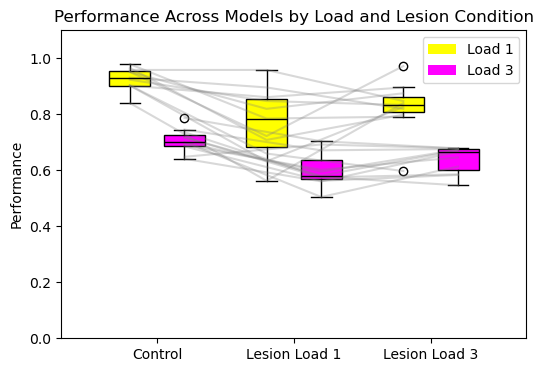

In [12]:
# plot summary paired boxplots with all models together

x_labels = ['Control', 'Lesion Load 1', 'Lesion Load 3']
x = np.arange(len(x_labels))

plt.figure(figsize=(6,4))
plt.boxplot(load1_perfs, positions=x-0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='yellow', color='black'), medianprops=dict(color='black'), labels=x_labels)
plt.boxplot(load3_perfs, positions=x+0.2, widths=0.3, patch_artist=True, boxprops=dict(facecolor='magenta', color='black'), medianprops=dict(color='black'), labels=x_labels)

from scipy.stats import wilcoxon
_, p = wilcoxon(load1_perfs[:, 0], load1_perfs[:, 1])
print(f"Wilcoxon test for Load 1: Control vs Lesion Load 1, p-value = {p:.4f}")
# plt.text(0.8, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load1_perfs[:, 0], load1_perfs[:, 2])
print(f"Wilcoxon test for Load 1: Control vs Lesion Load 3, p-value = {p:.4f}")
# plt.text(1.8, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load3_perfs[:, 1], load3_perfs[:, 2])
print(f"Wilcoxon test for Load 3: Lesion Load 1 vs Lesion Load 3, p-value = {p:.4f}")

_, p = wilcoxon(load3_perfs[:, 0], load3_perfs[:, 1])
print(f"Wilcoxon test for Load 3: Control vs Lesion Load 1, p-value = {p:.4f}")
# plt.text(1.2, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load3_perfs[:, 0], load3_perfs[:, 2])
print(f"Wilcoxon test for Load 3: Control vs Lesion Load 3, p-value = {p:.4f}")
# plt.text(2.2, 0.2, f"p={p:.3f}", ha='center', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)

_, p = wilcoxon(load1_perfs[:, 1], load1_perfs[:, 2])
print(f"Wilcoxon test for Load 1: Lesion Load 1 vs Lesion Load 3, p-value = {p:.4f}")

# draw gray lines
for i in range(len(model_names)):
    plt.plot(x-0.2, load1_perfs[i, :], color='gray', alpha=0.3)
    plt.plot(x+0.2, load3_perfs[i, :], color='gray', alpha=0.3)


plt.xticks(x, x_labels)
plt.ylabel('Performance')
plt.title('Performance Across Models by Load and Lesion Condition')
plt.legend([plt.Rectangle((0,0),1,1,facecolor='yellow'), plt.Rectangle((0,0),1,1,facecolor='magenta')], 
           ['Load 1', 'Load 3'], loc='upper right')
plt.ylim(0, 1.1)
plt.show()

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


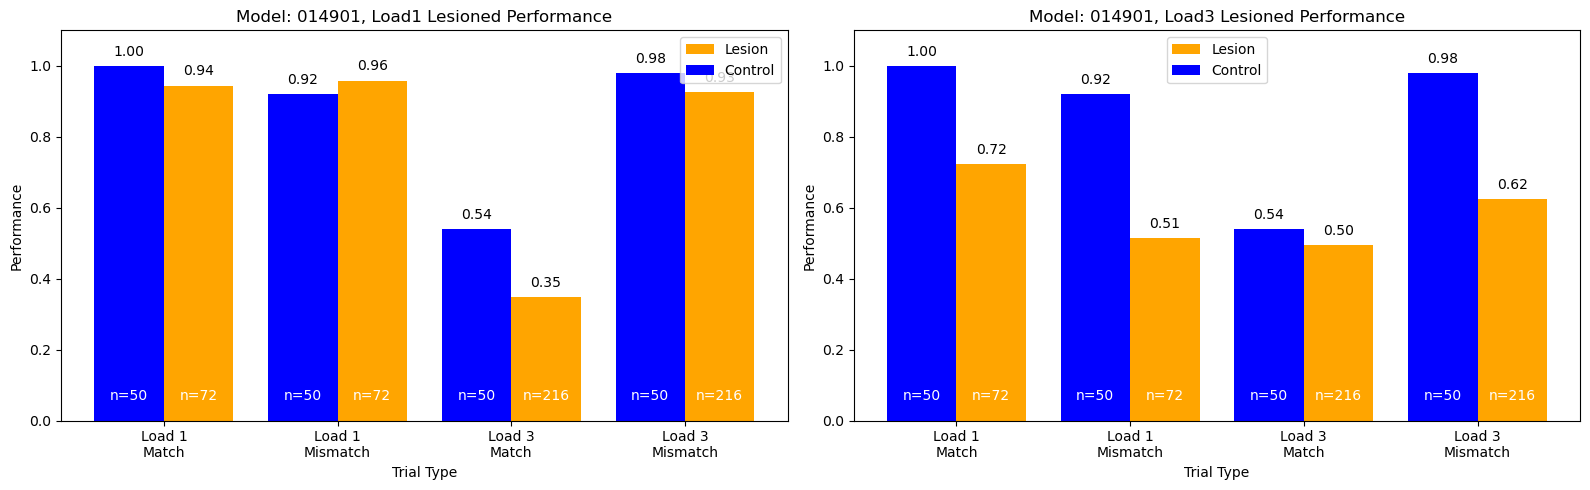

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


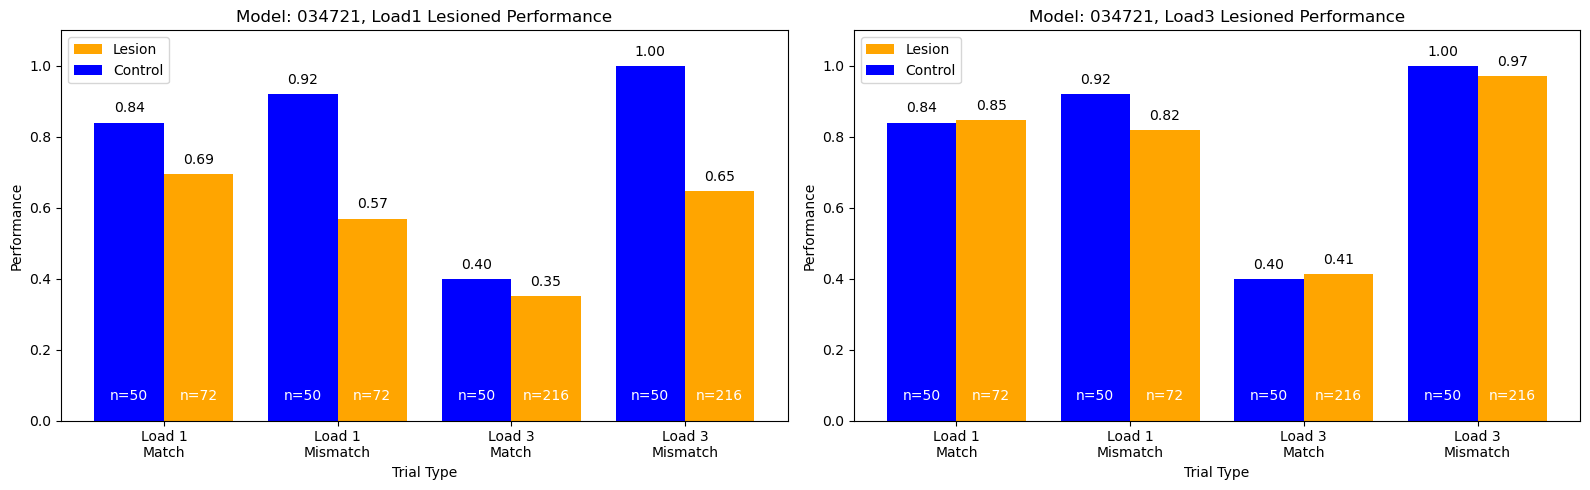

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


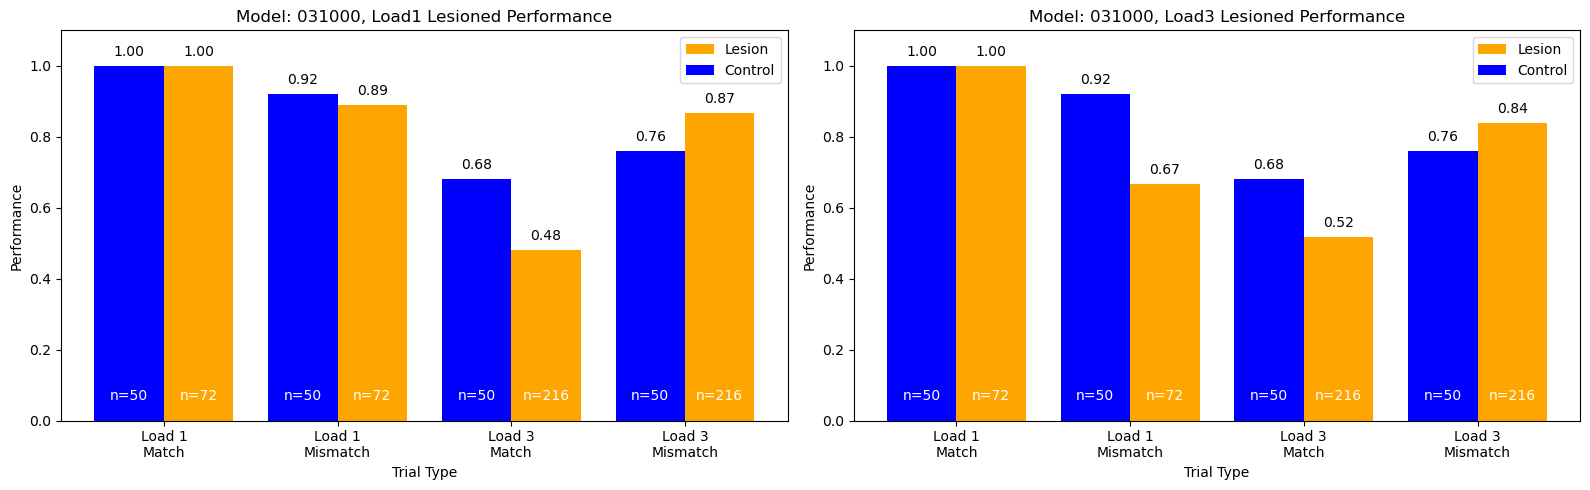

/tmp/ipykernel_835171/3650538290.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


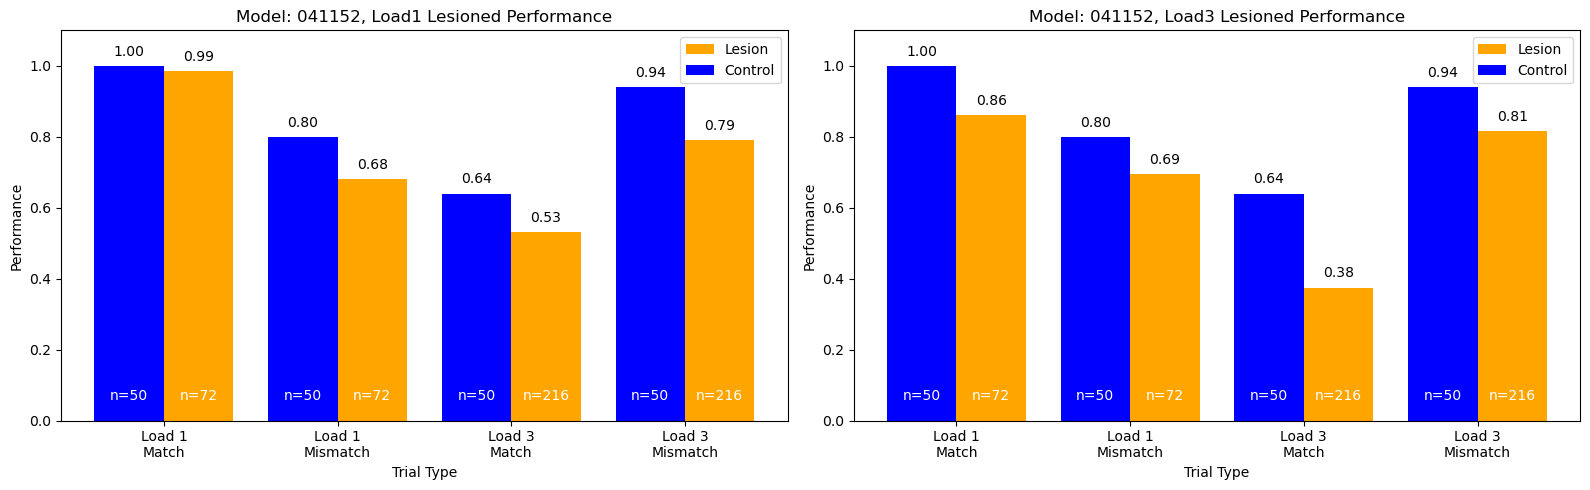

In [ ]:
# OLD

import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

for model_name in model_names[:4]: # start with first 4 models for testing

    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    load_selective = np.where(~np.isnan(load_tuning))[0]
    load_tuning = load_tuning[load_selective]

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='balance_match',
        all_models_dir=all_models_dir
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for i, load_lesion in enumerate([1, 3]):
        other_labels = f'precomputed_lesion_stimnan_maint_loadpref_{load_lesion:g}'.format(load_lesion)
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )
        
        # compare performance of lesion vs control, split by load & match/mismatch
        perfs_lesion = []
        perfs_ctrl = []
        n_lesion_trials = []
        n_ctrl_trials = []
        x_labels = []
        for j, load in enumerate([1, 3]):
            for k, match in enumerate([1, -1]):  # 1 = match, -1 = mismatch
                lesion_trial_idxs = np.where((trial_labels[:, 0] == load) & (trial_labels[:, 1] == match))[0]
                perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
                n_lesion_trials.append(len(lesion_trial_idxs))
                ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load) & (trial_labels_ctrl[:, 1] == match))[0]
                perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
                n_ctrl_trials.append(len(ctrl_trial_idxs))
                x_labels.append(f"Load {load}\n{'Match' if match == 1 else 'Mismatch'}")
        axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
        axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
        # show n inside bars
        for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
            axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
            axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].set_ylabel("Performance")
        axs[i].set_xlabel("Trial Type")
        axs[i].set_xticks(np.arange(len(perfs_lesion)))
        axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
        axs[i].set_ylim(0, 1.1)
        axs[i].legend()
        axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")
    
    plt.tight_layout()
    plt.show()

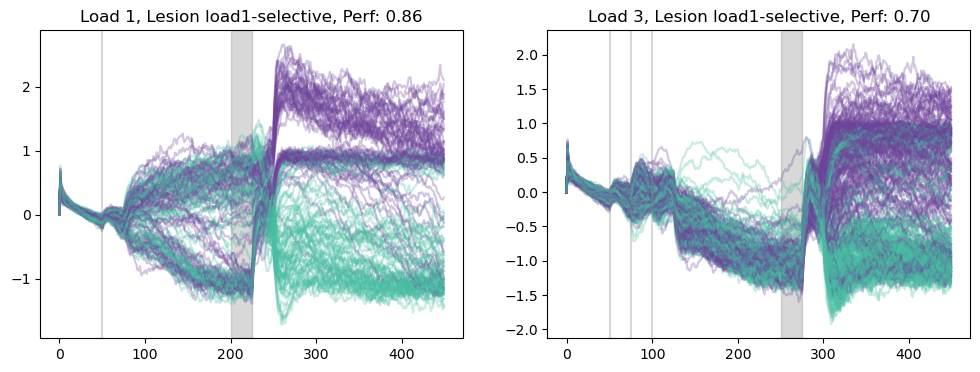

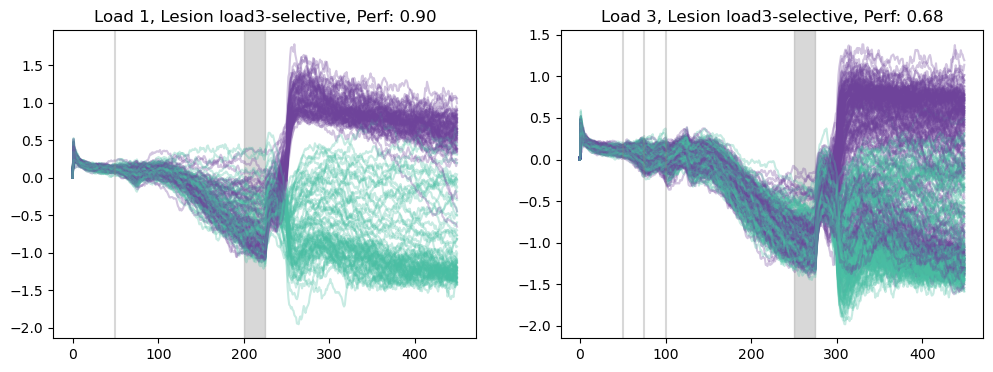

In [13]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_stimnan_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

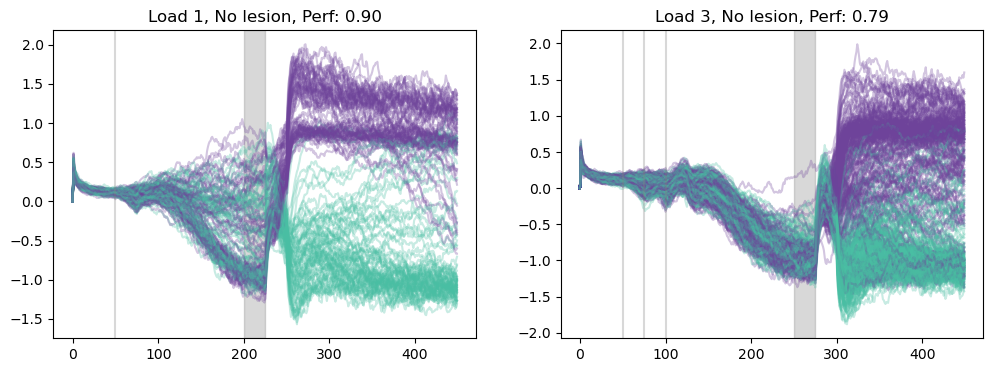

In [15]:
# compare to the normal
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
other_labels=f'precomputed.'
trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels=other_labels,
                                                    all_models_dir=all_models_dir)

# plot outputs
colors = ["#49BEA3", "#6E439A"]
fig, axs = plt.subplots(1,2, figsize=(12,4))
for i, load in enumerate([1, 3]):
    this_load_idx = np.where(trial_labels[:, 0] == load)[0]
    for n in this_load_idx:
        axs[i].plot(
            trial_outputs[n],
            color=colors[int(trial_labels[n,1] == 1)],
            alpha=0.3,
        )

    perf = np.mean(np.array(trial_perfs)[this_load_idx])
    axs[i].set_title(f"Load {load}, No lesion, Perf: {perf:.2f}")
    for n in range(load):
        stim_on = settings["stim_on"] + n * settings["stim_dur"]
        axs[i].axvline(stim_on, color="gray", alpha=0.3)
    axs[i].axvspan(
        stim_on + settings["delay"],
        stim_on + settings["delay"] + settings["stim_dur"],
        color="gray",
        alpha=0.3,
    )
plt.show()

In [32]:
settings

{'T': 450,
 'stim_on': 50,
 'stim_dur': 25,
 'delay': 150,
 'DeltaT': 1,
 'taus': 20,
 'fs': 200,
 'task': 'sternberg',
 'load': 1}

In [15]:
# try using a shorter cut-off for the evaluation period

def recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings, eval_dur=50):
    """
    Recalculate trial_perfs from trial_outputs using a threshold.
    """
    threshold=0.7

    trial_perfs_recalc = np.zeros_like(trial_perfs)
    for i, (labels, outputs) in enumerate(zip(trial_labels, trial_outputs)):
        load = int(labels[0])
        label = int(labels[1])
        resp_onset = int(settings["stim_on"] + load * settings["stim_dur"] + 
                         settings["delay"] + settings["stim_dur"] + 10)
        resp_offset = int(resp_onset + eval_dur)
        if label == 1:
            trial_perfs_recalc[i] = int(np.max(outputs[resp_onset:resp_offset]) > threshold)
        else:
            trial_perfs_recalc[i] = int(np.min(outputs[resp_onset:resp_offset]) < -threshold)

    print(f"Original trial_perfs: {np.mean(trial_perfs):.3f}")
    print(f"Recalculated trial_perfs: {np.mean(trial_perfs_recalc):.3f}")

    return trial_perfs_recalc

Original trial_perfs: 0.705
Recalculated trial_perfs: 0.658


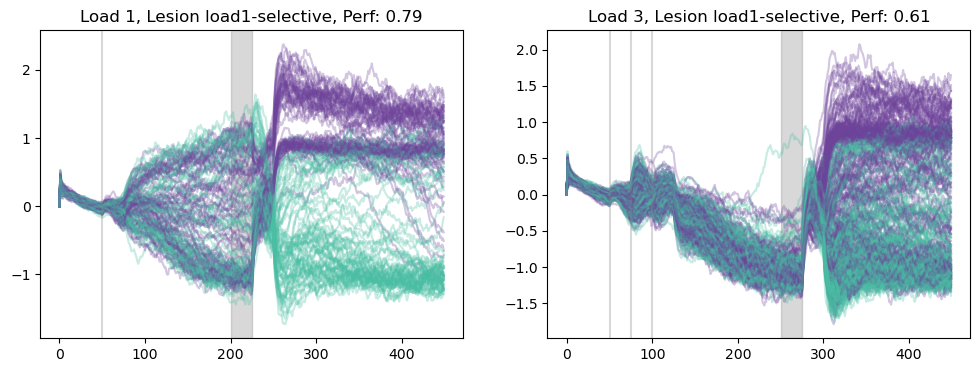

Original trial_perfs: 0.641
Recalculated trial_perfs: 0.632


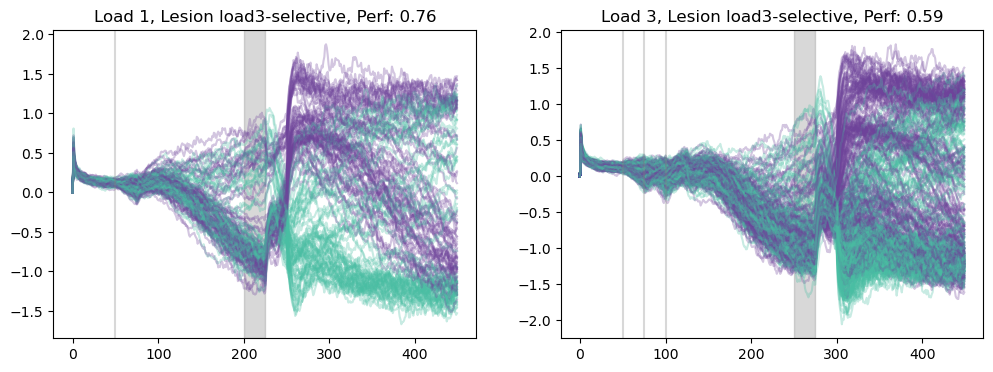

In [16]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    trial_perfs_recalc = recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings, eval_dur=50)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs_recalc)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

Original trial_perfs: 0.705
Recalculated trial_perfs: 0.658


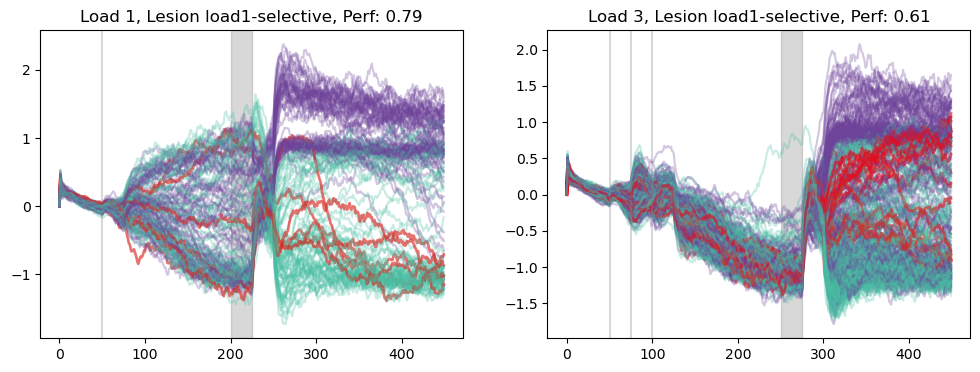

Original trial_perfs: 0.641
Recalculated trial_perfs: 0.632


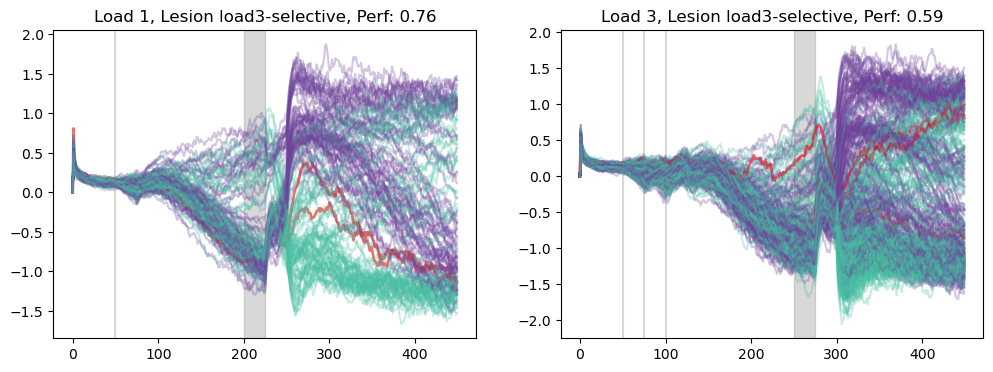

In [17]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[3]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_maint_loadpref_{load_lesion:g}'.format(load_lesion)
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    trial_perfs_recalc = recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings, eval_dur=50)
    
    changed_idxs = np.where(trial_perfs != trial_perfs_recalc)[0]
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )
            if n in changed_idxs:
                axs[i].plot(
                    trial_outputs[n],
                    color='red',
                    alpha=0.5,
                    linewidth=2,
                )

        perf = np.mean(np.array(trial_perfs_recalc)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()